In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Set a clean and presentation-friendly visual style
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [3]:
# Define project paths
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

excel_path = DATA_RAW / "Raisin_Dataset.xlsx"

df = pd.read_excel(excel_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [4]:
csv_path = DATA_RAW / "raisin_dataset.csv"

df.to_csv(csv_path, index=False)

print(f"CSV file saved to: {csv_path}")

CSV file saved to: ..\..\data\raw\raisin_dataset.csv


In [5]:
df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [6]:
df.shape

(900, 8)

In [7]:
df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    str    
dtypes: float64(5), int64(2), str(1)
memory usage: 56.4 KB


In [9]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [10]:
df.isna().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [11]:
df["Class"].value_counts()

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

In [12]:
df["Class"].value_counts(normalize=True) * 100

Class
Kecimen    50.0
Besni      50.0
Name: proportion, dtype: float64

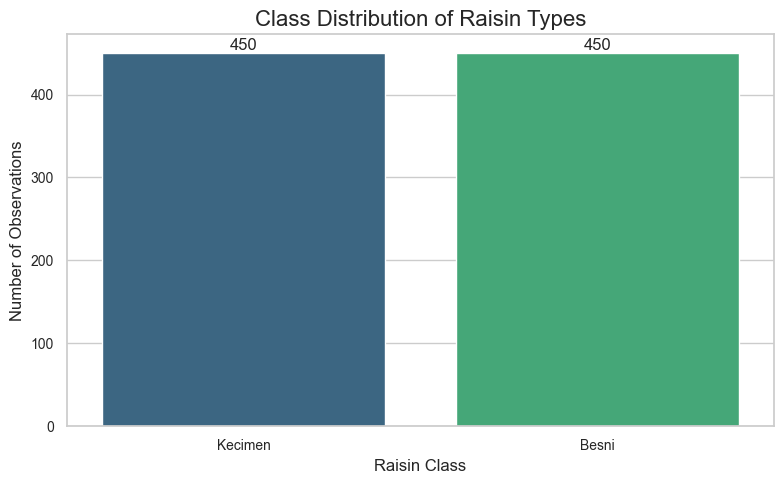

In [13]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette="viridis",
    legend=False
)

plt.title("Class Distribution of Raisin Types")
plt.xlabel("Raisin Class")
plt.ylabel("Number of Observations")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Target Balance

The dataset is perfectly balanced. It contains 450 observations of Kecimen raisins and 450 observations of Besni raisins.

This is a strong advantage for supervised classification because the model will learn from an equal number of examples from both classes. It also makes accuracy more meaningful compared to highly imbalanced datasets.